In [30]:
import numpy as np
import matplotlib.pyplot as plt

In [31]:
nu_inf = 1.5e-6      # Kinematic viscosity (m^2/s)
u_inf = 30         # Freestream velocity (m/s)
L = 1              # Characteristic length (m)
delta = 0.005        # Initial boundary layer thickness (m)

# Estimate initial x0 assuming standard laminar growth: delta approx 5.0 * sqrt(nu*x / u_inf)
x0 = (delta/5.0)**2*(u_inf/nu_inf) 
x_max = x0 + 40*L  # Marching up to 40 L downstream
dx = 0.01            # Marching step size in x

In [32]:

ny = 150  # Number of grid points in y
y_max = 1 # Maximum y domain height
s = 10  # Grid stretching factor

# Uniform computational grid (eta)
eta = np.linspace(0, 1, ny)
d_eta = eta[1]-eta[0]

# Physical stretched grid (y)
y = y_max * (np.sinh(s * eta) / np.sinh(s))

#proprosed stretching grid derivatives
deta_dy = np.sinh(s) / (s * y_max * np.cosh(s * eta))
d2eta_dy2 = -(np.sinh(s)**2 * np.sinh(s * eta)) / (s * y_max**2 * np.cosh(s * eta)**3)   #these were found symbolically with smpy and simplified, look at end of code.

In [33]:
u = np.zeros(ny)
v = np.zeros(ny)

#piecewise IC for u
for i in range(ny):
    if y[i]/delta <= 1:
        u[i] = u_inf*(y[i]/delta*(3/2-1/2*((y[i]/delta)**2)))
    else:
        u[i] = u_inf

In [34]:
#central diff for eta
D1 = np.zeros((ny, ny))
D2 = np.zeros((ny, ny))

for i in range(1, ny - 1):
    if i == 1 or i == ny - 2:
        #2nd order cd
        D1[i, i-1]= -1/(2*d_eta)
        D1[i, i+1]= 1/(2*d_eta)
        
        D2[i, i-1]= 1/d_eta**2
        D2[i, i]= -2/d_eta**2
        D2[i, i+1]= 1/d_eta**2
    else:
        #4th order cd
        D1[i, i-2]= 1/(12*d_eta)
        D1[i, i-1]= -8/(12*d_eta)
        D1[i, i+1]= 8/(12*d_eta)
        D1[i, i+2]= -1/(12*d_eta)
        
        D2[i, i-2]= -1/(12*d_eta**2)
        D2[i, i-1]= 16/(12*d_eta**2)
        D2[i, i]= -30/(12*d_eta**2)
        D2[i, i+1]= 16/(12*d_eta**2)
        D2[i, i+2]= -1/(12*d_eta**2)

In [ ]:
#C-N in x-dir
x = x0
x_storage_points = [x0 + 10*L, x0 + 20*L, x0 + 30*L, x0 + 40*L]
stored_profiles = {'y': y, x0: u.copy()}

while x < x_max:
    # 1. Calculate spatial differential operator matrix L_op
    L_matrix = np.zeros((ny, ny))
    for i in range(1, ny - 1):
        alpha = nu_inf * deta_dy[i]**2
        beta = nu_inf * d2eta_dy2[i] - v[i] * deta_dy[i]
        L_matrix[i, :] = (alpha * D2[i, :] + beta * D1[i, :]) / u[i]
        
    #init
    I = np.eye(ny)
    A = I - 0.5*dx*L_matrix
    b = I + 0.5*dx*L_matrix

    #top boundary
    A[-1, :] = 0; 
    A[-1, -1] = 1; 
    
    b[-1, :] = 0; 
    b[-1, -1] = u_inf 
    #bottom boundary
    A[0, :] = 0; 
    A[0, 0] = 1; 

    b[0, :] = 0; 
    b[0, 0] = 0        
    
    #rhs
    rhs = b@u
    rhs[0]=0
    rhs[-1]=u_inf
    
    u_new = np.linalg.solve(A, rhs)
    
    #
    du_dx = (u_new - u)/dx
    v_new = np.zeros(ny)
    for i in range(1, ny):
        v_new[i] = v_new[i-1] - 0.5*(y[i] - y[i-1]) * (du_dx[i] + du_dx[i-1])
        
    # 5. Update for next step
    u = u_new.copy()
    v = v_new.copy()
    x += dx
    
    # Store profiles at specific locations
    for target_x in x_storage_points.copy():
        if x >= target_x:
            stored_profiles[target_x] = u.copy()
            x_storage_points.remove(target_x)

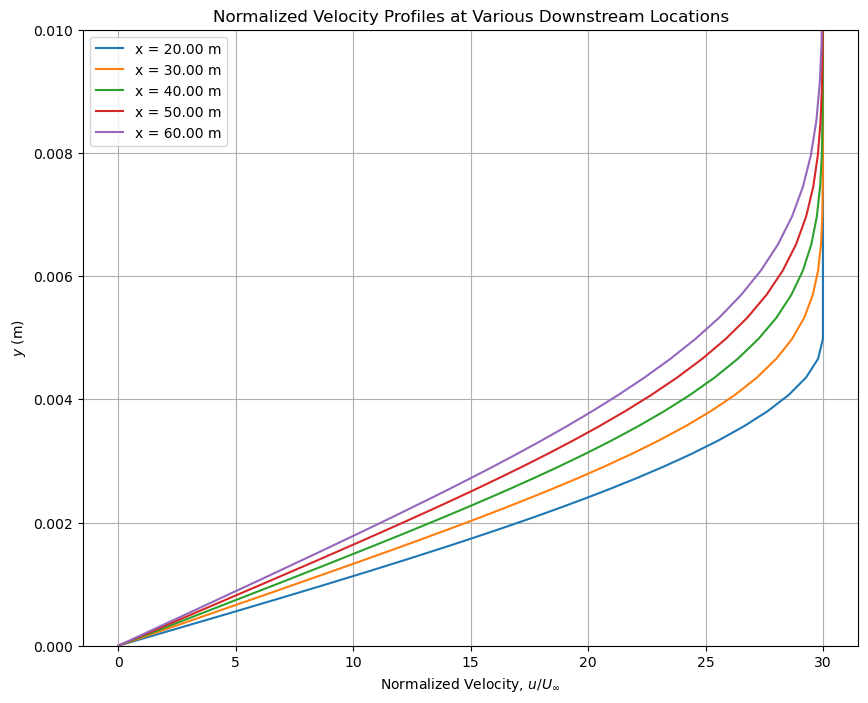

In [ ]:
#plot
plt.figure(figsize=(10, 8))

for x_loc, u_prof in stored_profiles.items():
    if x_loc != 'y':
        # --- Plotting ---
        plt.plot(u_prof/u_inf, y, label=f'x = {x_loc:.2f} m')

plt.title('Normalized Velocity Profiles at Various Downstream Locations')
plt.xlabel(r'Normalized Velocity, $u / U_{\infty}$')
plt.ylabel(r'$y$ (m)')
plt.ylim(0, 0.01) 
plt.legend()
plt.grid(True)
plt.show()

## Finding eta coordinate derivs:

In [ ]:
import sympy as sp
eta, s, y_max = sp.symbols('eta s y_max')

y = y_max * sp.sinh(s*eta) / sp.sinh(s)
dy_deta = sp.diff(y, eta)
d_eta=sp.simplify(dy_deta)
deta_dy = sp.simplify(1 / dy_deta)
d2_eta = sp.simplify(deta_dy * sp.diff(deta_dy, eta))
print(f"$$\n{sp.latex(d_eta)}\n$$")

$$
\frac{\partial\eta}{\partial y} = \frac{s y_{max} \cosh{\left(\eta s \right)}}{\sinh{\left(s \right)}}
$$

In [ ]:
print(f"$$\n{sp.latex(d2_eta)}\n$$")

$$
\frac{\partial^2\eta}{\partial y^2}=- \frac{\sinh^{2}{\left(s \right)} \sinh{\left(\eta s \right)}}{s y_{max}^{2} \cosh^{3}{\left(\eta s \right)}}
$$

        # --- Thickness Calculations using np.trapz ---
        integrand_disp = 1.0 - (u_prof / u_inf)
        disp_thick = np.trapezoid(integrand_disp, x=y)
        
        integrand_mom = (u_prof / u_inf) * (1.0 - (u_prof / u_inf))
        mom_thick = np.trapezoid(integrand_mom, x=y)
        
        # Shape factor
        shape_factor = disp_thick / mom_thick
        
        print(f"At x = {x_loc:.2f} m:")
        print(f"  Displacement Thickness: {disp_thick:.5f} m")
        print(f"  Momentum Thickness:     {mom_thick:.5f} m")
        print(f"  Shape Factor:           {shape_factor:.3f}\n")